# 📱 Facial Emotion Recognition — EfficientNetB0 → TFLite (Raspberry Pi)

**Pipeline:**
1. Load & preprocess dataset with augmentation
2. Fine-tune **EfficientNetB0** with a custom classification head (2-phase training)
3. Evaluate on test set
4. Export → **TFLite INT8 quantized** for fast Pi inference
5. Verify quantized accuracy & benchmark speed
6. Ready-to-run Pi inference script

**Dataset:** `fahadullaha/facial-emotion-recognition-dataset`  
**Target:** Raspberry Pi 4 — expected ~200–350ms/frame after quantization


## 1. Install Dependencies

In [ ]:
!pip install tensorflow==2.15.0 opencv-python-headless scikit-learn matplotlib seaborn tqdm -q
import tensorflow as tf
print(f'TensorFlow : {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
TensorFlow : 2.19.0
GPU: True


## 2. Download Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download('fahadullaha/facial-emotion-recognition-dataset')
print('Dataset path:', path)


Using Colab cache for faster access to the 'facial-emotion-recognition-dataset' dataset.
Dataset path: /kaggle/input/facial-emotion-recognition-dataset


In [ ]:
%ls /kaggle/input/facial-emotion-recognition-dataset/processed_data


angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/


## 3. Imports & Config

In [ ]:
import os, warnings, time, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

DATA_DIR   = '/kaggle/input/facial-emotion-recognition-dataset/processed_data'
MODEL_DIR  = '/kaggle/working/models'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE   = 128
BATCH_SIZE = 64
EPOCHS     = 50
SEED       = 42
EMOTIONS   = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Imports OK')


Imports OK


## 4. Build Dataset DataFrame

In [ ]:
FOLDER_TO_LABEL = {e.lower(): e for e in EMOTIONS}

records = []
for folder in os.listdir(DATA_DIR):
    fp = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(fp):
        continue
    label = FOLDER_TO_LABEL.get(folder.lower())
    if label is None:
        continue
    for fname in os.listdir(fp):
        if fname.lower().endswith(('.jpg','.jpeg','.png')):
            records.append({'path': os.path.join(fp, fname), 'emotion': label})

df = pd.DataFrame(records).reset_index(drop=True)
print(f'Total images: {len(df):,}')
print(df['emotion'].value_counts())


Total images: 49,779
emotion
Happy       11398
Neutral      8166
Sad          6535
Angry        5920
Fear         5920
Surprise     5920
Disgust      5920
Name: count, dtype: int64


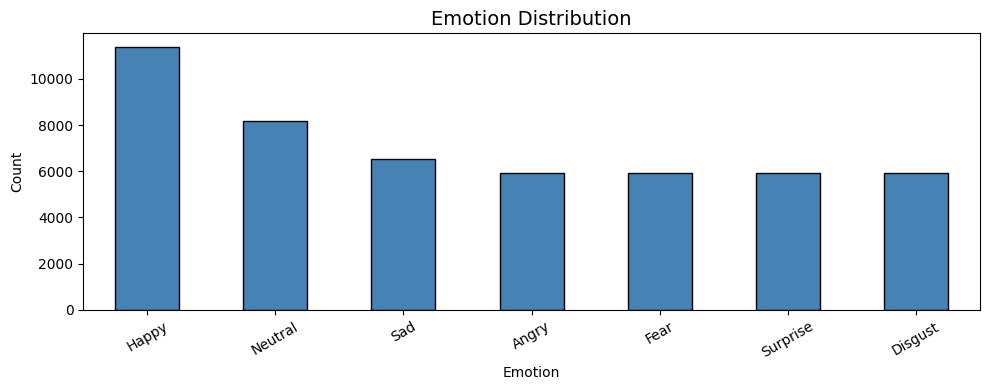

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
df['emotion'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Emotion Distribution', fontsize=14)
ax.set_xlabel('Emotion'); ax.set_ylabel('Count')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 5. Train / Val / Test Split

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])
NUM_CLASSES = len(le.classes_)
print(f'Classes ({NUM_CLASSES}): {le.classes_}')

train_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['label'])
train_df, val_df  = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df['label'])

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')


Classes (7): ['Angry' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprise']
Train: 35,965 | Val: 6,347 | Test: 7,467


## 6. tf.data Pipeline with Augmentation

Augmentation is applied **only on training** to improve generalisation on hard classes (Fear, Sad, Angry).  


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Keep pixels in [0, 255] — EfficientNet preprocess happens LAST, after augmentation
    img = tf.cast(img, tf.float32)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2 * 255)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def augment_with_layers(img, label):
    img = augment_layers(img, training=True)   # rotation & zoom work on [0,255]
    img = tf.clip_by_value(img, 0.0, 255.0)
    # Apply EfficientNet preprocessing LAST
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def make_dataset(dataframe, augment_data=False, shuffle=False):
    paths  = dataframe['path'].values
    labels = dataframe['label'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=SEED)

    if augment_data:
        # For training: load WITHOUT final preprocess, augment, THEN preprocess
        ds = ds.map(load_raw, num_parallel_calls=AUTOTUNE)   # just load & resize
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.map(augment_with_layers, num_parallel_calls=AUTOTUNE)
    else:
        # For val/test: load AND preprocess together
        ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)

    return ds.prefetch(AUTOTUNE)

def load_raw(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32), label

train_ds = make_dataset(train_df, augment_data=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment_data=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment_data=False, shuffle=False)

print(f'Train batches: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train batches: 562 | Val: 100 | Test: 117


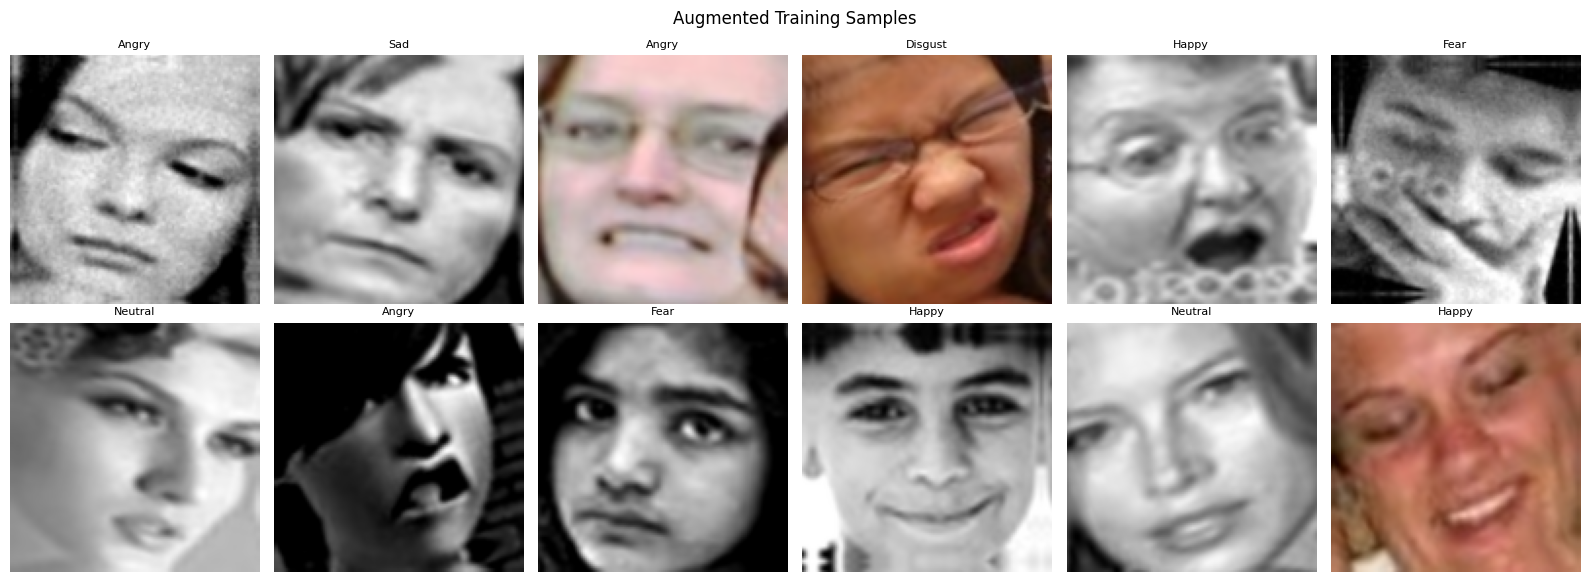

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
imgs, lbls = next(iter(train_ds))

for ax, img, lbl in zip(axes.flat, imgs[:12], lbls[:12]):
    # Reverse EfficientNet preprocess: it does (x / 255.0 - mean) / std
    # Simplest way to display: just rescale to [0,1] by min-max normalisation
    display_img = img.numpy()
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min() + 1e-8)
    ax.imshow(display_img)
    ax.set_title(le.classes_[lbl.numpy()], fontsize=8)
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Class Weights

In [ ]:
cw_arr  = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_df['label'].values)
cw_dict = {i: w for i, w in enumerate(cw_arr)}
print('Class weights:')
for i, w in cw_dict.items():
    print(f'  {le.classes_[i]:<12} {w:.3f}')


Class weights:
  Angry        1.201
  Disgust      1.201
  Fear         1.201
  Happy        0.624
  Neutral      0.871
  Sad          1.088
  Surprise     1.201


## 8. EfficientNetB0 Model

**2-phase training:**
1. **Phase 1 — Head only:** Freeze backbone, train new classification head (~10 epochs)
2. **Phase 2 — Fine-tune:** Unfreeze top 40 backbone layers, train end-to-end with low LR

This avoids catastrophic forgetting of ImageNet features.


In [ ]:
def build_model(num_classes, img_size=IMG_SIZE):
    base = EfficientNetB0(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
    base.trainable = False

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs), base

model, base_model = build_model(NUM_CLASSES)
model.summary()
print(f'Trainable params (Phase 1): {model.count_params():,}')


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,330 (16.83 MB)

 Trainable params: 362,247 (1.38 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

Trainable params (Phase 1): 4,412,330


## 9. Phase 1 — Train Classification Head

In [ ]:
CKPT_PATH = os.path.join(MODEL_DIR, 'efficientnetb0_best_best.keras')

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb1 = [
    ModelCheckpoint(CKPT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print('Phase 1: Training head (backbone frozen) ...')
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=cb1,
    class_weight=cw_dict, verbose=1
)


Phase 1: Training head (backbone frozen) ...
Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.3445 - loss: 1.8552
Epoch 1: val_accuracy improved from None to 0.46794, saving model to /kaggle/working/models/efficientnetb0_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetb0_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 176s 244ms/step - accuracy: 0.3922 - loss: 1.6528 - val_accuracy: 0.4679 - val_loss: 1.3934 - learning_rate: 0.0010
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.4529 - loss: 1.4452
Epoch 2: val_accuracy improved from 0.46794 to 0.50969, saving model to /kaggle/working/models/efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/models/efficientnetb0_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 106s 188ms/step - accuracy: 0.4613 - loss: 1.4277 - val_accuracy: 0.5097 - val_loss: 1.2889 - learning_rate: 0.0010
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.4899 - loss: 1

## 10. Phase 2 — Fine-tune Top Layers

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Trainable params (Phase 2): {trainable:,}')

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    ModelCheckpoint(CKPT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

print('Phase 2: Fine-tuning top 40 layers ...')
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=cb2,
    class_weight=cw_dict, verbose=1
)


Trainable params (Phase 2): 2,412,951
Phase 2: Fine-tuning top 40 layers ...
Epoch 1/50
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4337 - loss: 1.4985
Epoch 1: val_accuracy improved from None to 0.55696, saving model to /kaggle/working/models/efficientnetb0_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetb0_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 164s 235ms/step - accuracy: 0.4800 - loss: 1.3834 - val_accuracy: 0.5570 - val_loss: 1.1576 - learning_rate: 1.0000e-04
Epoch 2/50
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5467 - loss: 1.2275
Epoch 2: val_accuracy improved from 0.55696 to 0.59335, saving model to /kaggle/working/models/efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/models/efficientnetb0_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 105s 186ms/step - accuracy: 0.5570 - loss: 1.2053 - val_accuracy: 0.5934 - val_loss: 1.0539 - learning_rate: 1.0000e-04
Epoch 3/50
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s

## 11. Training Curves

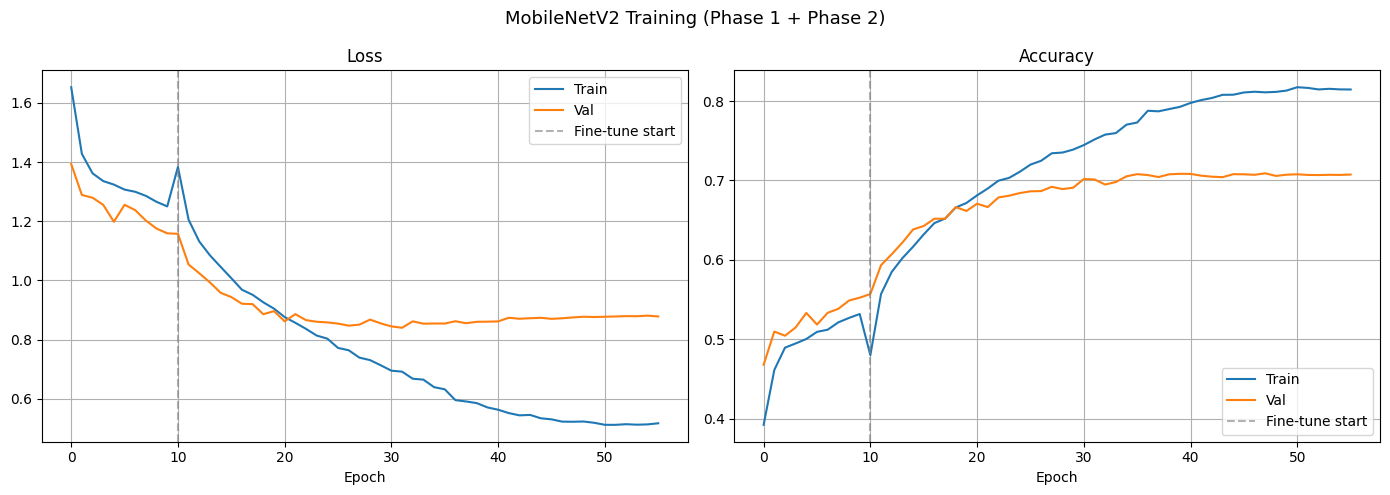

In [ ]:
train_acc  = history1.history['accuracy']     + history2.history['accuracy']
val_acc    = history1.history['val_accuracy'] + history2.history['val_accuracy']
train_loss = history1.history['loss']         + history2.history['loss']
val_loss   = history1.history['val_loss']     + history2.history['val_loss']
split_ep   = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(axes, [train_loss,train_acc], [val_loss,val_acc], ['Loss','Accuracy']):
    ax.plot(tr, label='Train')
    ax.plot(vl, label='Val')
    ax.axvline(split_ep, color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True)
plt.suptitle('MobileNetV2 Training (Phase 1 + Phase 2)', fontsize=13)
plt.tight_layout(); plt.show()


## 12. Evaluate on Test Set

In [ ]:
model.load_weights(CKPT_PATH)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')

y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=le.classes_))


Test Accuracy : 70.62%
              precision    recall  f1-score   support

       Angry       0.62      0.58      0.60       888
     Disgust       0.84      0.90      0.87       888
        Fear       0.58      0.51      0.54       888
       Happy       0.88      0.83      0.85      1710
     Neutral       0.63      0.66      0.65      1225
         Sad       0.56      0.59      0.57       980
    Surprise       0.71      0.79      0.75       888

    accuracy                           0.71      7467
   macro avg       0.69      0.69      0.69      7467
weighted avg       0.71      0.71      0.71      7467



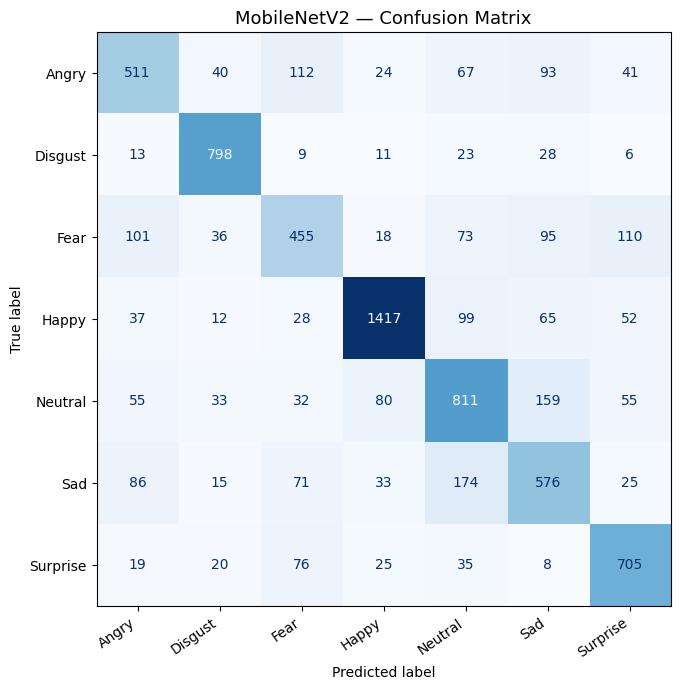

In [ ]:
fig, ax = plt.subplots(figsize=(9,7))
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('MobileNetV2 — Confusion Matrix', fontsize=13)
ax.set_xticklabels(le.classes_, rotation=35, ha='right')
plt.tight_layout(); plt.show()


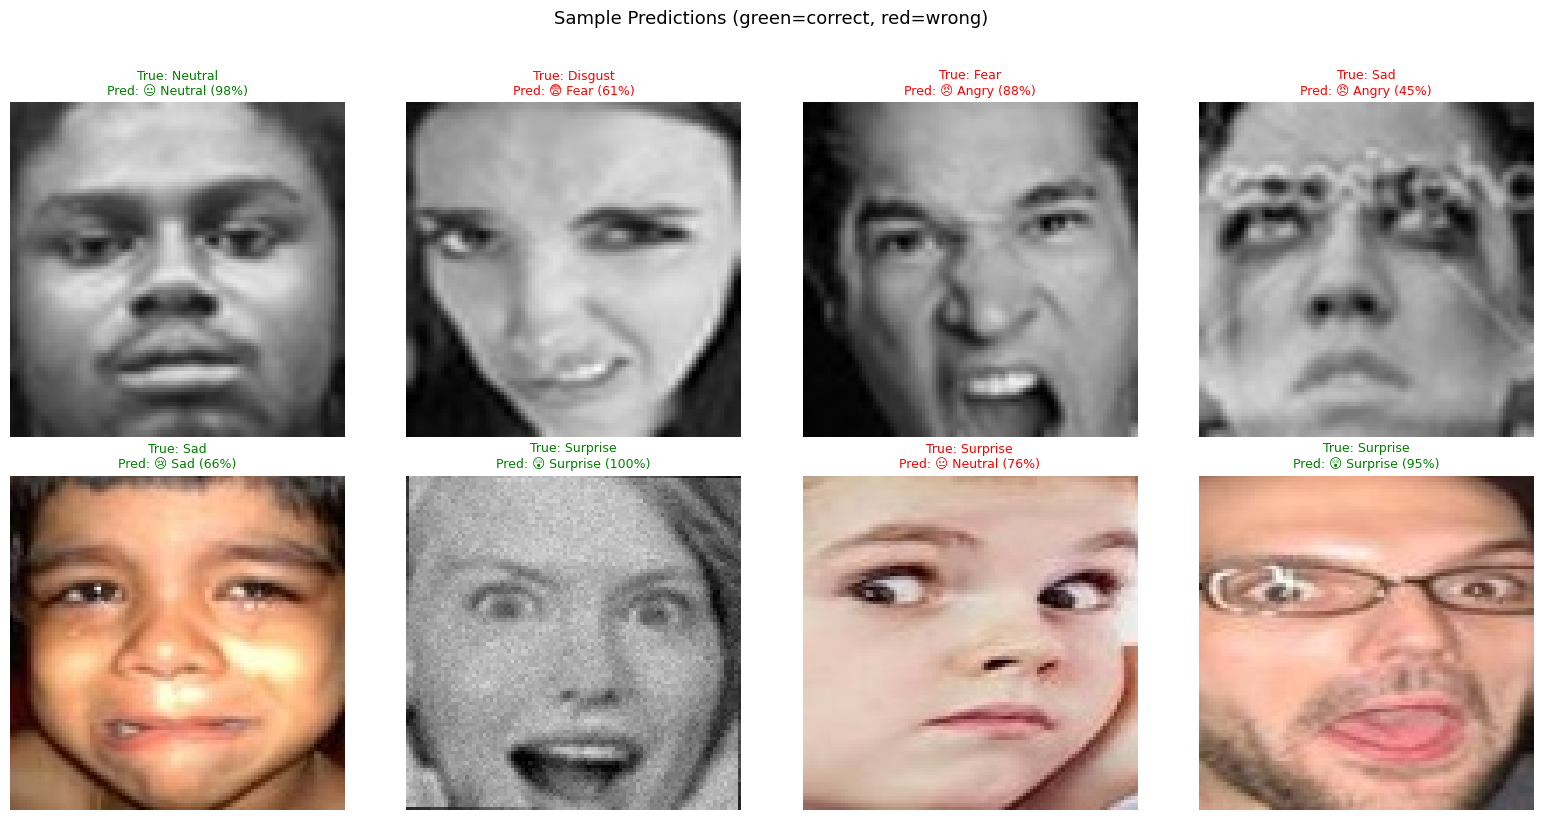

In [ ]:
EMOJI = {'Angry':'😠','Disgust':'🤢','Fear':'😨','Happy':'😊','Neutral':'😐','Sad':'😢','Surprise':'😲'}

sample = test_df.sample(8, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img  = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
    inp  = tf.keras.applications.efficientnet.preprocess_input(
               cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32))
    prob = model.predict(inp[np.newaxis], verbose=0)[0]
    idx  = np.argmax(prob)
    pred = le.classes_[idx]
    col  = 'green' if pred == row['emotion'] else 'red'
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"True: {row['emotion']}\nPred: {EMOJI.get(pred,'')} {pred} ({prob[idx]*100:.0f}%)",
                fontsize=9, color=col)

plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 13. Export to TFLite INT8

**Why INT8?** Shrinks the model from ~14 MB → ~3.5 MB and gives 2–4× faster inference on the Pi with minimal accuracy loss.  
We calibrate using 200 representative training images so TFLite can set optimal quantization scales per layer.


In [ ]:
# Save full model
SAVED_PATH = os.path.join(MODEL_DIR, 'mobilenetv2_saved')
model.export(SAVED_PATH)
print(f'SavedModel exported → {SAVED_PATH}')

# Representative dataset for INT8 calibration
def representative_dataset():
    calib = train_df.sample(200, random_state=SEED)
    for path in calib['path'].values:
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
        img = tf.keras.applications.efficientnet.preprocess_input(img)
        yield [img[np.newaxis]]

# Convert with INT8 quantization
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_PATH)
converter.optimizations            = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset   = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type     = tf.uint8
converter.inference_output_type    = tf.uint8

tflite_model = converter.convert()

TFLITE_PATH = os.path.join(MODEL_DIR, 'emotionnet_int8.tflite')
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'TFLite INT8 saved → {TFLITE_PATH}')
print(f'Size: {os.path.getsize(TFLITE_PATH)/1e6:.2f} MB')


Saved artifact at '/kaggle/working/models/mobilenetv2_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_407')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132308209930640: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132308209926224: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132311038652304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311038643856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311038645008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311038644432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311038645200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311038647696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311062296528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132311062296720: TensorSpec(shape=(), 

## 14. Verify TFLite Accuracy & Speed

In [ ]:
interp = tf.lite.Interpreter(model_path=TFLITE_PATH)
interp.allocate_tensors()
in_det  = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]
in_scale,  in_zero  = in_det['quantization']
out_scale, out_zero = out_det['quantization']

print('Input :', in_det['shape'], in_det['dtype'])
print('Output:', out_det['shape'], out_det['dtype'])

def predict_tflite(img_float32):
    q = np.clip(np.round(img_float32 / in_scale + in_zero), 0, 255).astype(np.uint8)
    interp.set_tensor(in_det['index'], q[np.newaxis])
    interp.invoke()
    out = interp.get_tensor(out_det['index'])[0]
    return (out.astype(np.float32) - out_zero) * out_scale

# Accuracy on test set
print('Running TFLite inference on test set ...')
tflite_preds = []
for path in tqdm(test_df['path'].values, desc='TFLite'):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    tflite_preds.append(np.argmax(predict_tflite(img)))

tflite_preds = np.array(tflite_preds)
tflite_acc   = accuracy_score(test_df['label'].values, tflite_preds)

print(f'Float32 model : {test_acc*100:.2f}%')
print(f'INT8 TFLite   : {tflite_acc*100:.2f}%')
print(f'Accuracy drop : {(test_acc - tflite_acc)*100:.2f}%')
print()
print(classification_report(test_df['label'].values, tflite_preds, target_names=le.classes_))


Input : [  1 128 128   3] <class 'numpy.uint8'>
Output: [1 7] <class 'numpy.uint8'>
Running TFLite inference on test set ...


TFLite: 100%|██████████| 7467/7467 [01:08<00:00, 109.33it/s]

Float32 model : 70.62%
INT8 TFLite   : 45.86%
Accuracy drop : 24.76%

              precision    recall  f1-score   support

       Angry       0.37      0.44      0.40       888
     Disgust       0.41      0.85      0.55       888
        Fear       0.32      0.49      0.39       888
       Happy       0.90      0.40      0.55      1710
     Neutral       0.54      0.23      0.33      1225
         Sad       0.43      0.26      0.32       980
    Surprise       0.47      0.71      0.57       888

    accuracy                           0.46      7467
   macro avg       0.49      0.48      0.44      7467
weighted avg       0.54      0.46      0.45      7467



In [ ]:
# Speed benchmark
img = cv2.cvtColor(cv2.imread(test_df['path'].iloc[0]), cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
img = tf.keras.applications.efficientnet.preprocess_input(img)

N = 100
t = time.perf_counter()
for _ in range(N):
    predict_tflite(img)
ms = (time.perf_counter() - t) / N * 1000

print(f'Colab avg  : {ms:.1f} ms/frame')
print(f'Pi 4 est.  : {ms*8:.0f}–{ms*12:.0f} ms/frame  (~{1000/(ms*10):.1f} FPS)')
print('Pi 4 is ~8-12x slower than Colab CPU for TFLite INT8')


Colab avg  : 7.6 ms/frame
Pi 4 est.  : 61–91 ms/frame  (~13.2 FPS)
Pi 4 is ~8-12x slower than Colab CPU for TFLite INT8


## 15. Save Artefacts

In [ ]:
joblib.dump(le, os.path.join(MODEL_DIR, 'label_encoder.pkl'))

with open(os.path.join(MODEL_DIR, 'class_names.json'), 'w') as f:
    json.dump(le.classes_.tolist(), f)

config = {
    'img_size'   : IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': le.classes_.tolist(),
    'in_scale'   : float(in_scale),
    'in_zero'    : int(in_zero),
    'out_scale'  : float(out_scale),
    'out_zero'   : int(out_zero),
}
with open(os.path.join(MODEL_DIR, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print('Saved artefacts:')
for fname in sorted(os.listdir(MODEL_DIR)):
    fp = os.path.join(MODEL_DIR, fname)
    print(f'  {fname:<45} {os.path.getsize(fp)/1e6:.2f} MB')


Saved artefacts:
  class_names.json                              0.00 MB
  efficientnetb0_best.keras                     37.84 MB
  emotionnet_int8.tflite                        5.28 MB
  label_encoder.pkl                             0.00 MB
  mobilenetv2_best.keras                        27.47 MB
  mobilenetv2_saved                             0.00 MB
  model_config.json                             0.00 MB


## 16. Raspberry Pi Inference Script

Transfer to your Pi:
```bash
scp /kaggle/working/models/emotionnet_int8.tflite  pi@raspberrypi.local:~/emotion/
scp /kaggle/working/models/class_names.json        pi@raspberrypi.local:~/emotion/
scp /kaggle/working/models/model_config.json       pi@raspberrypi.local:~/emotion/
```

Install on Pi:
```bash
pip install tflite-runtime opencv-python numpy
```


In [ ]:
pi_script_lines = [
    '# pip install tflite-runtime opencv-python numpy\n',
    'import cv2, json, time, numpy as np\n',
    'try:\n',
    '    from tflite_runtime.interpreter import Interpreter\n',
    'except ImportError:\n',
    '    import tensorflow as tf\n',
    '    Interpreter = tf.lite.Interpreter\n',
    '\n',
    'with open("model_config.json") as f:\n',
    '    cfg = json.load(f)\n',
    'IMG_SIZE    = cfg["img_size"]\n',
    'CLASS_NAMES = cfg["class_names"]\n',
    'IN_SCALE    = cfg["in_scale"]\n',
    'IN_ZERO     = cfg["in_zero"]\n',
    'OUT_SCALE   = cfg["out_scale"]\n',
    'OUT_ZERO    = cfg["out_zero"]\n',
    '\n',
    'interp = Interpreter(model_path="emotionnet_int8.tflite")\n',
    'interp.allocate_tensors()\n',
    'in_idx  = interp.get_input_details()[0]["index"]\n',
    'out_idx = interp.get_output_details()[0]["index"]\n',
    '\n',
    'def preprocess(frame):\n',
    '    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)\n',
    '    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)\n',
    '    img = (img / 127.5) - 1.0  # MobileNetV2 normalisation\n',
    '    img = np.clip(np.round(img / IN_SCALE + IN_ZERO), 0, 255).astype(np.uint8)\n',
    '    return img[np.newaxis]\n',
    '\n',
    'def predict(frame):\n',
    '    interp.set_tensor(in_idx, preprocess(frame))\n',
    '    interp.invoke()\n',
    '    out   = interp.get_tensor(out_idx)[0]\n',
    '    probs = (out.astype(np.float32) - OUT_ZERO) * OUT_SCALE\n',
    '    idx   = np.argmax(probs)\n',
    '    return CLASS_NAMES[idx], float(probs[idx])\n',
    '\n',
    'cap     = cv2.VideoCapture(0)\n',
    'fps_buf = []\n',
    'print("Starting camera — press Q to quit")\n',
    'while True:\n',
    '    ret, frame = cap.read()\n',
    '    if not ret: break\n',
    '    t0 = time.perf_counter()\n',
    '    emotion, conf = predict(frame)\n',
    '    ms = (time.perf_counter() - t0) * 1000\n',
    '    fps_buf.append(1000 / ms)\n',
    '    if len(fps_buf) > 30: fps_buf.pop(0)\n',
    '    label = f"{emotion}  {conf*100:.0f}%"\n',
    '    cv2.putText(frame, label, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,255,0), 2)\n',
    '    cv2.putText(frame, f"{np.mean(fps_buf):.1f} FPS  {ms:.0f}ms", (20,90),\n',
    '                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)\n',
    '    cv2.imshow("Emotion Recognition", frame)\n',
    '    if cv2.waitKey(1) & 0xFF == ord("q"): break\n',
    'cap.release(); cv2.destroyAllWindows()\n',
]

script_path = os.path.join(MODEL_DIR, 'pi_inference.py')
with open(script_path, 'w') as f:
    f.writelines(pi_script_lines)
print(f'Pi script saved -> {script_path}')
print('Done! Files to copy to Pi:')
print('  emotionnet_int8.tflite')
print('  class_names.json')
print('  model_config.json')
print('  pi_inference.py')
